In [6]:
import pandas as pd
import json
import re
import random
from collections import Counter, defaultdict

In [2]:
old_df = pd.read_json("/fs/ess/PAS1576/qwjian/webarena_s/WebRL/LLaMA-Factory/data/web_policy_sft.json")
old_df.head()

,conversations
0,"[{'from': 'human', 'value': 'Task Instruction:..."
1,"[{'from': 'human', 'value': 'Task Instruction:..."
2,"[{'from': 'human', 'value': 'Task Instruction:..."
3,"[{'from': 'human', 'value': 'Task Instruction:..."
4,"[{'from': 'human', 'value': 'Task Instruction:..."


In [ ]:
from transformers import AutoTokenizer
llama3_tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")
qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")

In [ ]:
print(old_df.iloc[i]['conversations'][0]['value'])

Task Instruction: In the philosophy subreddit, find the new post discussing the Western philosophy's efforts to distinguish humans from animals and give a thumbs up to the author ADefiniteDescription.

Round 0

<|eot_id|><|start_header_id|>user<|end_header_id|>
In the philosophy subreddit, find the new post discussing the Western philosophy's efforts to distinguish humans from animals and give a thumbs up to the author ADefiniteDescription.

<|eot_id|><|start_header_id|>assistant<|end_header_id|>
# Element: the 'Forums' link at the top center
do(action="Click", element="1")

Round 1

<|eot_id|><|start_header_id|>user<|end_header_id|>
** Simplified html **

<|eot_id|><|start_header_id|>assistant<|end_header_id|>
# Element: the 'Alphabetical' navigation link at the top center
do(action="Click", element="13")

Round 2

<|eot_id|><|start_header_id|>user<|end_header_id|>
** Simplified html **

<|eot_id|><|start_header_id|>assistant<|end_header_id|>
# Element: the 'philosophy' link among a l

In [ ]:
def is_html(text):
    return text.strip().startswith('<html') or text.strip().startswith('<')


def parse_old_template(msg):
    """
    Parse the old template format from webarena_sft_openai.parquet
    
    Input format:
    msg[0] (role='user'): Task Instruction + history rounds + current observation
    msg[1] (role='assistant'): response/action
    
    Returns dict with:
    - task_instruction: the task description
    - num_rounds: total number of rounds
    - history_details: list of (observation, action) tuples for completed rounds (excludes current)
    - current_observation: the current observation awaiting response
    - response: the expected action/response (from msg[1])
    """
    content = msg[0]['value']
    response = msg[1]['value'] if len(msg) > 1 else ""
    
    # Find the first round marker position
    first_round_match = re.search(r'\n\nRound 0\n\n', content)
    if first_round_match:
        # Task instruction is everything after "Task Instruction: " up to (but not including) "\n\nRound 0"
        task_instruction = content[len("Task Instruction: "):first_round_match.start()]
    else:
        task_instruction = ""
    
    # Split by rounds - use lookahead to keep the delimiter info
    # Pattern: \n\nRound N\n\n
    round_split_pattern = r'\n\nRound (\d+)\n\n'
    
    # Find all round positions
    rounds_info = list(re.finditer(round_split_pattern, content))
    
    all_rounds = []
    user_marker = '<|eot_id|><|start_header_id|>user<|end_header_id|>\n'
    assistant_marker = '<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n'
    
    for i, match in enumerate(rounds_info):
        round_num = int(match.group(1))
        start_pos = match.end()  # Position after "\n\nRound N\n\n"
        
        # End position is either next round start or end of content
        if i + 1 < len(rounds_info):
            end_pos = rounds_info[i + 1].start()
        else:
            end_pos = len(content)
        
        round_content = content[start_pos:end_pos]
        
        obs = ""
        action = ""
        
        if user_marker in round_content:
            user_start = round_content.find(user_marker) + len(user_marker)
            if assistant_marker in round_content:
                assistant_start = round_content.find(assistant_marker)
                # Content between user marker and assistant marker
                obs = round_content[user_start:assistant_start].rstrip('\n')
                action = round_content[assistant_start + len(assistant_marker):]
            else:
                # Only observation, no action (last round)
                obs = round_content[user_start:]
        if round_num == 0 and not is_html(obs):
            assert obs == task_instruction, f"task instruction mismatch for round 0\noriginal: {task_instruction}\nrecord: {obs}"
        all_rounds.append({
            "round": round_num,
            "observation": obs,
            "action": action
        })
    
    num_rounds = len(all_rounds)
    
    # Separate history (all but last) from current (last round)
    if all_rounds:
        history_details = all_rounds[:-1]  # All completed rounds
        last_round = all_rounds[-1]
        current_observation = last_round["observation"]
    else:
        history_details = []
        current_observation = ""
    
    return {
        "task_instruction": task_instruction,
        "num_rounds": num_rounds,
        "history_details": history_details,
        "current_observation": current_observation,
        "response": response
    }

In [ ]:
old_df.iloc[15]['conversations'][0]['value']

'Task Instruction: Obtain the ID information for all products where the name is \'Hero Hoodie\' and the type is \'Configurable Product\'.\n\nRound 0\n\n<|eot_id|><|start_header_id|>user<|end_header_id|>\n<html data-bbox="0,0,1280,720"> <body data-bbox="0,0,1280,1618"> <div data-bbox="0,0,88,721"> <img id="0" title="Magento Admin Panel" data-bbox="27,17,35,41"> </img> <ul data-bbox="0,75,88,646"> <span id="1" data-bbox="14,112,60,13"> Dashboard </span> <li data-bbox="0,137,88,62"> <span id="2" data-bbox="30,174,28,13"> Sales </span> <div data-bbox="-180,0,268,812"> <strong data-bbox="-150,20,180,30"> Sales </strong> <li data-bbox="-165,92,238,308"> <ul data-bbox="-165,92,238,308"> <span data-bbox="-150,369,174,19"> Braintree Virtual Terminal </span> </ul> </li> </div> </li> <li data-bbox="0,199,88,62"> <span id="3" data-bbox="22,236,44,13"> Catalog </span> <div data-bbox="-180,0,268,812"> <strong data-bbox="-150,20,180,30"> Catalog </strong> <li data-bbox="-165,92,238,88"> <ul data-bbox

In [ ]:
errors = set()
for i in range(len(old_df)):
    try:
        parsed = parse_old_template(old_df.iloc[i]['conversations'])
    except Exception as e:
        print(f"Error parsing sample {i}: {e}")
        errors.add(i)
print(f"Total errors: {len(errors)}")


Error parsing sample 3: task instruction mismatch for round 0
original: Among the top 10 posts in "DIY" forum, identify the projects that involve woodworking.
record: Thumbs down the top 2 posts ever in DIY.
Error parsing sample 31: task instruction mismatch for round 0
original: Among the top 10 posts in "AskReddit" forum, identify any post that includes a question about social media usage and list the author's name.
record: Thumbs down the top 2 posts ever in AskReddit.
Error parsing sample 45: task instruction mismatch for round 0
original: Like all submissions created by PupsandKittens1512 in subreddit aww.
record: DisLike all submissions created by abesster in subreddit aww.
Error parsing sample 74: task instruction mismatch for round 0
original: Follow ghost lahwaacz on Gitlab
record: Follow ['ghost', 'lahwaacz'] on Gitlab
Error parsing sample 93: task instruction mismatch for round 0
original: set my homepage url to https://1029.com
record: set the homepage URL on my GitLab prof

In [ ]:
filtered_df = old_df.drop(list(errors))
len(filtered_df)

9086

In [ ]:
# Test the parser
sample_idx = random.randint(0, len(filtered_df))
parsed = parse_old_template(filtered_df.iloc[sample_idx]['conversations'])

print(f"Task Instruction: {parsed['task_instruction'][:200]}...")
print(f"Number of rounds: {parsed['num_rounds']}")
print(f"\nHistory details:")
for rd in parsed['history_details']:
    print(f"  Round {rd['round']}:")
    print(f"    Observation: {rd['observation'][:100]}..." if len(rd['observation']) > 100 else f"    Observation: {rd['observation']}")
    print(f"    Action: {rd['action'][:100]}..." if len(rd['action']) > 100 else f"    Action: {rd['action']}")
print(f"\nCurrent observation: {parsed['current_observation'][:200]}..." if parsed['current_observation'] else "\nCurrent observation: (empty)")
print(f"Response: {parsed['response'][:200]}..." if parsed['response'] else "Response: (empty)")

Task Instruction: Please gather all orders from March 2nd, 2022 to August 10th, 2022 and sum up the total price for me....
Number of rounds: 8

History details:
  Round 0:
    Observation: Please gather all orders from March 2nd, 2022 to August 10th, 2022 and sum up the total price for me...
    Action: # Element: the 'My Account' link
do(action="Click", element="0")
  Round 1:
    Observation: ** Simplified html **
    Action: # Element: the 'My Orders' link
do(action="Click", element="38")
  Round 2:
    Observation: ** Simplified html **
    Action: do(action="Scroll Down")
  Round 3:
    Observation: ** Simplified html **
    Action: # Element: the 'Next' button for pagination
do(action="Click", element="17")
  Round 4:
    Observation: ** Simplified html **
    Action: do(action="Scroll Down")
  Round 5:
    Observation: ** Simplified html **
    Action: # Element: the 'Next page' link
do(action="Click", element="18")
  Round 6:
    Observation: ** Simplified html **
    Action: #

In [ ]:
# validate: recover original template from parsed result
def recover_old_template(parsed):
    """Reconstruct the original content from parsed dict using old header format."""
    user_marker = '<|eot_id|><|start_header_id|>user<|end_header_id|>\n'
    assistant_marker = '<|eot_id|><|start_header_id|>assistant<|end_header_id|>\n'
    
    # Build task instruction header
    content = f"Task Instruction: {parsed['task_instruction']}"
    
    # Build history rounds
    for rd in parsed['history_details']:
        content += f"\n\nRound {rd['round']}\n\n"
        content += user_marker
        content += rd['observation']
        content += f"\n\n{assistant_marker}"
        content += rd['action']
    
    # Build current round (last round)
    if parsed['current_observation']:
        current_round = len(parsed['history_details'])
        content += f"\n\nRound {current_round}\n\n"
        content += user_marker
        content += parsed['current_observation']
        content += f"\n\n{assistant_marker}"
    
    return content

# Double check: compare original vs recovered
def validate_parsing(msg):
    """Validate that parse + recover gives back the original content."""
    original = msg[0]['value']
    parsed = parse_old_template(msg)
    recovered = recover_old_template(parsed)
    
    match = original == recovered
    
    if match:
        # print("✓ MATCH: Parsing is correct!")
        return parsed
    else:
        print("✗ MISMATCH: Parsing has issues")
        # Find first difference
        for i, (o, r) in enumerate(zip(original, recovered)):
            if o != r:
                print(f"  First diff at position {i}:")
                print(f"    Original:  {repr(original[max(0,i-20):i+50])}")
                print(f"    Recovered: {repr(recovered[max(0,i-20):i+50])}")
                break
        if len(original) != len(recovered):
            print(f"  Length diff: original={len(original)}, recovered={len(recovered)}")

        return False

# Test on all samples
print("Testing parsing on all samples:")
failed = []
parsed_result_list = []
for idx in range(len(filtered_df)):
    result = validate_parsing(filtered_df.iloc[idx]['conversations'])
    if not result:
        failed.append(idx)
    else:
        parsed_result_list.append(result)
        
if failed:
    print(f"Failed on {len(failed)} samples: {failed[:10]}...")
    # Show first failure details
    print("\nFirst failure details:")
    validate_parsing(filtered_df.iloc[failed[0]]['conversations'], verbose=True)
else:
    print(f"✓ All {len(filtered_df)} samples passed!")

Testing parsing on all samples:
✓ All 9086 samples passed!


In [ ]:
def convert_to_simplified_format(parsed):
    """
    Convert parsed data to simplified format (no special tokens, but keep original structure).
    
    Format:
    Task Instruction: {task}

    Round 0

    User:
    {observation_0}

    Assistant:
    {action_0}

    Round 1

    User:
    {observation_1}

    Assistant:
    {action_1}
    ...
    """
    # Build content
    content = f"Task Instruction: {parsed['task_instruction']}"
    
    # History rounds
    for rd in parsed['history_details']:
        content += f"\n\nRound {rd['round']}\n\n"
        content += f"user:\n{rd['observation']}\n\n"
        content += f"assistant:\n{rd['action']}"
    
    # Current round
    current_round = len(parsed['history_details'])
    content += f"\n\nRound {current_round}\n\n"
    content += f"user:\n{parsed['current_observation']}\n\n"
    content += "assistant:\n"
    
    return {
        "prompt": content,
        "response": parsed['response']
    }

# Test conversion
sample = parsed_result_list[4]
simplified = convert_to_simplified_format(sample)

print("=== Simplified Format (no special tokens) ===")
print(simplified['prompt'][:1500])
print("...")
print(f"\n[Expected Response]: {simplified['response'][:200]}...")

=== Simplified Format (no special tokens) ===
Task Instruction: Like the submission by moon___fish discussing strategies to avoid US politics on Reddit, which is the 6th most active post in the AskReddit subreddit.

Round 0

user:
Like the submission by moon___fish discussing strategies to avoid US politics on Reddit, which is the 6th most active post in the AskReddit subreddit.

assistant:
# Element: the 'Forums' link at the top center
do(action="Click", element="1")

Round 1

user:
** Simplified html **

assistant:
# Element: the 'AskReddit' forum link at the top center
do(action="Click", element="13")

Round 2

user:
** Simplified html **

assistant:
# Element: the 'AskReddit' link within the 'All forums' list
do(action="Click", element="17")

Round 3

user:
<html data-bbox="0,0,1280,720"> <body data-bbox="0,0,1280,2439"> <div data-bbox="14,706,0,0"> </div> <nav data-bbox="0,0,1280,0"> </nav> <nav data-bbox="0,0,1280,52"> <div data-bbox="90,0,1100,52"> <header data-bbox="104,0,90,52

In [ ]:
print(qwen_tokenizer.chat_template)

{%- if tools %}
    {{- '<|im_start|>system\n' }}
    {%- if messages[0].role == 'system' %}
        {{- messages[0].content + '\n\n' }}
    {%- endif %}
    {{- "# Tools\n\nYou may call one or more functions to assist with the user query.\n\nYou are provided with function signatures within <tools></tools> XML tags:\n<tools>" }}
    {%- for tool in tools %}
        {{- "\n" }}
        {{- tool | tojson }}
    {%- endfor %}
    {{- "\n</tools>\n\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\n<tool_call>\n{\"name\": <function-name>, \"arguments\": <args-json-object>}\n</tool_call><|im_end|>\n" }}
{%- else %}
    {%- if messages[0].role == 'system' %}
        {{- '<|im_start|>system\n' + messages[0].content + '<|im_end|>\n' }}
    {%- endif %}
{%- endif %}
{%- set ns = namespace(multi_step_tool=true, last_query_index=messages|length - 1) %}
{%- for message in messages[::-1] %}
    {%- set index = (messages|length - 

## weave raw obs together

In [ ]:
from collections import defaultdict
task_to_records = defaultdict(dict)

for i, parsed in enumerate(parsed_result_list):
    task_instruction = parsed['task_instruction']
    current_round = len(parsed['history_details'])
    current_observation = parsed['current_observation']
    current_action = parsed['response']
    
    # sanity check
    records = task_to_records[task_instruction]
    for rd in parsed['history_details']:
        if rd['round'] in records:
            action_in_history = rd['action']
            action_in_record = records[rd['round']]['action']
            if action_in_history != action_in_record:
                print(f"action mismatch for round {rd['round']}\nhistory: {action_in_history}\nrecord: {action_in_record}")
            # try:
            #     assert action_in_history == action_in_record, f"action mismatch for round {rd['round']}\nhistory: {action_in_history}\nrecord: {action_in_record}"
            # except Exception as e:
            #     # print(f"Error at sample {i}, round {rd['round']}: {e}")
            #     continue
    task_to_records[task_instruction][current_round] = {
        'observation': current_observation,
        'action': current_action,
        'source': i
    }
        


action mismatch for round 4
history: # Element: the project title 'n-lab / cloud-to-butt
do(action="Click", element="36")
record: # Element: the 'n-lab / cloud-to-butt' link
do(action="Click", element="36")


In [ ]:
len(task_to_records)

1113

In [ ]:
task_to_records.keys()

dict_keys(["Establish a new discussion platform called 'VirtualRealityVanguard'. It should serve as a cutting-edge forum where VR aficionados can engage in conversations about the newest trends, games, and applications in the virtual reality realm. Please ensure the sidebar features the following tags: virtual reality, technology, trends, gaming.", 'Which are the top 5 items with the highest sales in June 2022?', 'Extract the price section of the best-selling products report for the yearlong period from March 1, 2022, to December 31, 2022.', "Create an issue in timeit repo with title 'Timeit Code Optimization'. Assign the issue to myself. Set due date to be 2023-10-30.", 'Like the submission by moon___fish discussing strategies to avoid US politics on Reddit, which is the 6th most active post in the AskReddit subreddit.', "Modify the status of the review for the 'Supernova Sport Pant' product to be 'Pending'.", 'Carry out the action of printing credit memos for orders specified as comp

In [ ]:
for task_inst, traj_records in task_to_records.items():
    for i_round in range(len(traj_records)):
        if i_round not in traj_records:
            print(f"missing round {i_round} for task {task_inst}")


In [ ]:
# prepare to save

processed_trajs = []
for task_inst, traj_records in task_to_records.items():
    each_rounds = []
    for i_round in range(len(traj_records)):
        each_rounds.append({
            'i_round': i_round,
            'observation': traj_records[i_round]['observation'],
            'action': traj_records[i_round]['action'],
        })
    processed_trajs.append({
        'task_instruction': task_inst,
        'total_rounds': len(traj_records),
        'rounds': each_rounds
    })





In [1]:
import json

output_path = "/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_merged_trajectories.json"

In [ ]:
# Save processed trajectories

with open(output_path, 'w') as f:
    json.dump(processed_trajs, f, indent=2)

print(f"Saved {len(processed_trajs)} trajectories to {output_path}")

Saved 1114 trajectories to /fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_merged_trajectories.json


In [2]:
# load
processed_trajs = json.load(open(output_path))

In [ ]:
print("# Setup\nYou are a professional web browsing agent assistant that can fulfill user's high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. \n# More details about the code\nYour code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:\n\n```\ndef do(action, argument, element):\n\t\"\"\"A single browsing operation on the webpage.\n\tArgs:\n\t\t:param action: one of the actions from [\"Click\", \"Right Click\", \"Type\", \"Search\", \"Hover\", \"Scroll Up\", \"Scroll Down\", \"Press Enter\", \"Switch Tab\", \"Select Dropdown Option\", \"Wait\"].\n\t\t:param argument: optional. Only for \"Type\", \"Search\", \"Switch Page\", and \"Select Dropdown Option\", indicating the content to type in, page number(start from 0) to switch, or key to press.\n\t\t                           \"Search\" action is equivalent to \"Type\" action plus \"Enter\" key press.\n\t\t:param element: optional. Only for \"Click\", \"Right Click\", \"Type\", \"Search\", \"Select Dropdown Option\", and \"Hover\". Should be specific element id in the html.\n\tReturns:\n\t\tNone. The webpage will be updated after executing the action.\n\t\"\"\"\n\ndef exit(message):\n\t\"\"\"Ending the browsing process if the assistant think it has fulfilled the goal.\n\tArgs:\n\t\t:param message: optional. If user's instruction is a question, return assistant's answer in the message based on the browsing content.\n\tReturns:\n\t\tNone.\n\t\"\"\"\n\ndef go_backward():\n\t\"\"\"Go back to the previous page.\n\t\"\"\"\n\ndef go_forward():\n  \"\"\"Go forward to the next page.\n  \"\"\"\n```\n\nHere are some examples:\n- # Element: the 'REPORTS' section on the left sidebar\ndo(action=\"Click\", element=\"7\")\n- # Element: the 'Period' dropdown, middle center\ndo(action=\"Select Dropdown Option\", argument=\"Month\", element=\"20\")\n- # Element: the 'From' date picker input field, middle center\ndo(action=\"Type\", argument=\"01/01/2023\", element=\"22\")\n- do(action=\"Scroll Down\")\n- exit(message=\"The top-3 best-selling products in January 2023 are: 1\")\n- # Element: The search bar\ndo(action=\"Search\", argument=\"international airport near Carnegie Mellon University within a driving distance of 50 km\", element=\"13\")\n- # Note: Pittsburgh International Airport, Southern Beltway, Findlay Township, Allegheny County, 15231, United States\n# Element: The field labeled 'Pittsburgh International Airport' in the top left corner\ndo(action=\"Type\", argument=\"Cleveland Hopkins International Airport\", element=\"14\")\n\nREMEMBER: \n- only **ONE-LINE-OF-CODE** at a time\n- Don't generate an operation element that you do not see in the screenshot.\n- Use \"# Element\" to describe the element you choose in the html.\n- Use '# Note\" to record information useful to answer the instruction if needed.\n- If you find yourself fallen into some sort of loop, try to use another method or change your action.\n- If you think a page is still loading or still playing animation and you want to wait a while, use \"Wait\" action.\n- You are acting in a real world, try your best not to reject user's demand. Solve all the problem you encounter.\n- If you think you didn't get expected webpage, you should try using more precise and locative description of the element.\n- You must make sure the target element of `find_element*` exists on current screenshot, if not, you should navigate to the target place first.\n- You must identify potential errors or mistakes made by `find_element*` function and correct them. If the webpage is not as expected, you should try to re-do or un-do the operation.\n- You should **NEVER** try to use the browser's address bar at the top of the page to navigate.\n- Your answer shouldn't be in a code snippet format. Just write the function name and its arguments.\n- For quote, exit, go_backward, go_forward request, you should strictly obey the format of quote, exit, go_backward, go_forward functions, answers like do(\"Quote\", xxx, None) or  do(\"quote\", xxx, None)are not allowed.\n- If you use do function to perform \"Click\", \"Right Click\", \"Type\", \"Search\", \"Select Dropdown Option\", and \"Hover\", the param element must not be None.\n", )

# Setup
You are a professional web browsing agent assistant that can fulfill user's high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. 
# More details about the code
Your code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:

```
def do(action, argument, element):
	"""A single browsing operation on the webpage.
	Args:
		:param action: one of the actions from ["Click", "Right Click", "Type", "Search", "Hover", "Scroll Up", "Scroll Down", "Press Enter", "Switch Tab", "Select Dropdown Option", "Wait"].
		:param argument: optional. Only for "Type", "Search", "Switch Page", and "Select Dropdown Option", indicating the content to type in, page number(start from 0) to switch, or key to p

In [14]:
system_prompt =  "# Setup\nYou are a professional web browsing agent assistant that can fulfill user's high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. \n# More details about the code\nYour code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:\n\n```\ndef do(action, argument, element):\n\t\"\"\"A single browsing operation on the webpage.\n\tArgs:\n\t\t:param action: one of the actions from [\"Click\", \"Right Click\", \"Type\", \"Search\", \"Hover\", \"Scroll Up\", \"Scroll Down\", \"Press Enter\", \"Switch Tab\", \"Select Dropdown Option\", \"Wait\"].\n\t\t:param argument: optional. Only for \"Type\", \"Search\", \"Switch Page\", and \"Select Dropdown Option\", indicating the content to type in, page number(start from 0) to switch, or key to press.\n\t\t                           \"Search\" action is equivalent to \"Type\" action plus \"Enter\" key press.\n\t\t:param element: optional. Only for \"Click\", \"Right Click\", \"Type\", \"Search\", \"Select Dropdown Option\", and \"Hover\". Should be specific element id in the html.\n\tReturns:\n\t\tNone. The webpage will be updated after executing the action.\n\t\"\"\"\n\ndef exit(message):\n\t\"\"\"Ending the browsing process if the assistant think it has fulfilled the goal.\n\tArgs:\n\t\t:param message: optional. If user's instruction is a question, return assistant's answer in the message based on the browsing content.\n\tReturns:\n\t\tNone.\n\t\"\"\"\n\ndef go_backward():\n\t\"\"\"Go back to the previous page.\n\t\"\"\"\n\ndef go_forward():\n  \"\"\"Go forward to the next page.\n  \"\"\"\n```\n\nHere are some examples:\n- # Element: the 'REPORTS' section on the left sidebar\ndo(action=\"Click\", element=\"7\")\n- # Element: the 'Period' dropdown, middle center\ndo(action=\"Select Dropdown Option\", argument=\"Month\", element=\"20\")\n- # Element: the 'From' date picker input field, middle center\ndo(action=\"Type\", argument=\"01/01/2023\", element=\"22\")\n- do(action=\"Scroll Down\")\n- exit(message=\"The top-3 best-selling products in January 2023 are: 1\")\n- # Element: The search bar\ndo(action=\"Search\", argument=\"international airport near Carnegie Mellon University within a driving distance of 50 km\", element=\"13\")\n- # Note: Pittsburgh International Airport, Southern Beltway, Findlay Township, Allegheny County, 15231, United States\n# Element: The field labeled 'Pittsburgh International Airport' in the top left corner\ndo(action=\"Type\", argument=\"Cleveland Hopkins International Airport\", element=\"14\")\n\nREMEMBER: \n- only **ONE-LINE-OF-CODE** at a time\n- Don't generate an operation element that you do not see in the screenshot.\n- Use \"# Element\" to describe the element you choose in the html.\n- Use '# Note\" to record information useful to answer the instruction if needed.\n- If you find yourself fallen into some sort of loop, try to use another method or change your action.\n- If you think a page is still loading or still playing animation and you want to wait a while, use \"Wait\" action.\n- You are acting in a real world, try your best not to reject user's demand. Solve all the problem you encounter.\n- If you think you didn't get expected webpage, you should try using more precise and locative description of the element.\n- You must make sure the target element of `find_element*` exists on current screenshot, if not, you should navigate to the target place first.\n- You must identify potential errors or mistakes made by `find_element*` function and correct them. If the webpage is not as expected, you should try to re-do or un-do the operation.\n- You should **NEVER** try to use the browser's address bar at the top of the page to navigate.\n- Your answer shouldn't be in a code snippet format. Just write the function name and its arguments.\n- For quote, exit, go_backward, go_forward request, you should strictly obey the format of quote, exit, go_backward, go_forward functions, answers like do(\"Quote\", xxx, None) or  do(\"quote\", xxx, None)are not allowed.\n- If you use do function to perform \"Click\", \"Right Click\", \"Type\", \"Search\", \"Select Dropdown Option\", and \"Hover\", the param element must not be None.\n"
memory_system_prompt =  f"{system_prompt}- You must combine your memories and the current observation to form a comprehensive understanding of the current situation."
print(memory_system_prompt)

# Setup
You are a professional web browsing agent assistant that can fulfill user's high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. 
# More details about the code
Your code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:

```
def do(action, argument, element):
	"""A single browsing operation on the webpage.
	Args:
		:param action: one of the actions from ["Click", "Right Click", "Type", "Search", "Hover", "Scroll Up", "Scroll Down", "Press Enter", "Switch Tab", "Select Dropdown Option", "Wait"].
		:param argument: optional. Only for "Type", "Search", "Switch Page", and "Select Dropdown Option", indicating the content to type in, page number(start from 0) to switch, or key to p

In [ ]:
# Convert merged trajectories back to SFT format (one sample per step)
# This creates training samples where each sample is a (prompt, response) pair

def trajectory_to_baseline_samples(traj):
    """
    Convert a merged trajectory to SFT training samples.
    For each round, create a sample with:
    - prompt: task instruction + all previous rounds + current observation
    - response: current action
    """
    samples = []
    task_inst = traj['task_instruction']
    
    for current_round_idx in range(traj['total_rounds']):
        # Build prompt
        prompt = f"Task Instruction: {task_inst}"
        
        # Add history rounds
        for prev_round in range(current_round_idx):
            rd = traj['rounds'][prev_round]
            prompt += f"\n\nRound {prev_round}\n\n"
            if is_html(rd['observation']):
                prompt += f"user:\n** Simplified html **\n\n"
            else:
                prompt += f"user:\n{rd['observation']}\n\n"
            prompt += f"assistant:\n{rd['action']}"
        
        # Add current round (observation only)
        current_rd = traj['rounds'][current_round_idx]
        prompt += f"\n\nRound {current_round_idx}\n\n"
        prompt += f"user:\n{current_rd['observation']}\n\n"
        
        samples.append({
            "prompt": prompt,
            "response": current_rd['action'],
            "task_instruction": task_inst,
            "round": current_round_idx,
            "total_rounds": traj['total_rounds']
        })
    
    return samples

# Generate all SFT samples
all_sft_samples = []
for traj in processed_trajs:
    all_sft_samples.extend(trajectory_to_baseline_samples(traj))

print(f"Total SFT samples: {len(all_sft_samples)}")
print(f"Sample distribution by round:")
round_dist = Counter([s['round'] for s in all_sft_samples])
print(round_dist)

Total SFT samples: 9029
Sample distribution by round:
Counter({0: 1113, 1: 1072, 2: 1066, 3: 1007, 4: 948, 5: 872, 6: 748, 7: 626, 8: 471, 9: 269, 10: 165, 11: 98, 12: 74, 13: 62, 14: 46, 15: 43, 16: 39, 17: 34, 18: 33, 19: 31, 20: 28, 21: 26, 22: 24, 23: 23, 24: 22, 25: 21, 26: 18, 27: 5, 28: 3, 29: 3, 30: 3, 31: 3, 32: 3, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1})


In [ ]:
sft_df_for_parquet = pd.DataFrame({
    'messages': [
        json.dumps([
            {
                'role': 'system',
                'content': system_prompt
            },
            {
                'role': 'user',
                'content': s['prompt']
            },
            {
                'role': 'assistant',
                'content': s['response']
            }
        ])
        for s in all_sft_samples
    ],
})
sft_df_for_parquet.head()

,messages
0,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
1,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
2,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
3,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
4,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."


In [140]:
sft_df_for_parquet.to_parquet("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_baseline_sft.parquet")

In [ ]:

# def make_prompt_input_for_webshop_repeat_obs(
#     task_description,
#     step_count,
#     memory_history,
#     current_step,
#     current_observation,
#     available_actions
# ) -> List[Dict]:
#     """Build prompt input with memory history for full training."""
#     memory_prompt = []
#     for mem in memory_history:
#         memory_prompt.append({'type': 'memory_text', 'memory_text': {'text': mem['obs']}})
#         memory_prompt.append({'type': 'text', 'text': f"""{mem['act']}"""})

#     return [
#         {'type': 'text', 'text': f"""You are an expert autonomous agent operating in the WebShop e‑commerce environment.
# Your task is to: {task_description}.

# === BEGIN OF MEMORY ===
# """},
#         *memory_prompt,
#         {'type': 'text', 'text': f"""=== END OF MEMORY ===

# You are now at step {current_step} and your current observation is: """},
#     {'type': 'memory_text', 'memory_text': {'text': current_observation}, 'is_memory': False},
#     {'type': 'text', 'text': f""" {current_observation}.
# Your admissible actions of the current situation are:
# [
# {available_actions}
# ].

# Now it's your turn to take one action for the current step.
# Before choosing your action, you MUST combine your memories and the current observation to form a comprehensive understanding of the current situation.
# Once you've finished your reasoning, you should choose an admissible action for current step and present it within <action> </action> tags.
# """},
#     ]



# Setup
You are a professional web browsing agent assistant that can fulfill user's high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. 
# More details about the code
Your code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:

```
def do(action, argument, element):
	"""A single browsing operation on the webpage.
	Args:
		:param action: one of the actions from ["Click", "Right Click", "Type", "Search", "Hover", "Scroll Up", "Scroll Down", "Press Enter", "Switch Tab", "Select Dropdown Option", "Wait"].
		:param argument: optional. Only for "Type", "Search", "Switch Page", and "Select Dropdown Option", indicating the content to type in, page number(start from 0) to switch, or key to p

In [ ]:
def trajectory_to_repeat_obs_samples(traj):
    """
    Convert a merged trajectory to SFT training samples.
    For each round, create a sample with:
    - prompt: task instruction + all previous rounds + current observation
    - response: current action
    """
    samples = []
    task_inst = traj['task_instruction']
    
    for current_round_idx in range(traj['total_rounds']):
        # Build prompt
        prompt_list = []
        prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}"})
        
        # Add history rounds
        for prev_round in range(current_round_idx):
            rd = traj['rounds'][prev_round]
            prompt_list.append({'type': 'text', 'text': f"\n\nRound {prev_round}\n observation:"})
            prompt_list.append({'type': 'memory_text', 'memory_text': {'text': rd['observation']}})
            prompt_list.append({'type': 'text', 'text': f"action: {rd['action']}"})
        
        # Add current round (observation only)
        current_rd = traj['rounds'][current_round_idx]
        prompt_list.append({'type': 'text', 'text': f"\n\nRound {current_round_idx}\n observation: {current_rd['observation']}"})
        prompt_list.append({'type': 'memory_text', 'memory_text': {'text': current_rd['observation']}, 'is_memory': False})
        
        samples.append({
            "prompt": prompt_list,
            "response": current_rd['action'],
            "task_instruction": task_inst,
            "round": current_round_idx,
            "total_rounds": traj['total_rounds']
        })
    
    return samples

# Generate all SFT samples
all_sft_repeat_obs_samples = []
for traj in processed_trajs:
    all_sft_repeat_obs_samples.extend(trajectory_to_repeat_obs_samples(traj))

print(f"Total SFT Memorysamples: {len(all_sft_repeat_obs_samples)}")
print(f"Sample distribution by round:")
round_dist = Counter([s['round'] for s in all_sft_repeat_obs_samples])
print(round_dist)

Total SFT Memorysamples: 9029
Sample distribution by round:
Counter({0: 1113, 1: 1072, 2: 1066, 3: 1007, 4: 948, 5: 872, 6: 748, 7: 626, 8: 471, 9: 269, 10: 165, 11: 98, 12: 74, 13: 62, 14: 46, 15: 43, 16: 39, 17: 34, 18: 33, 19: 31, 20: 28, 21: 26, 22: 24, 23: 23, 24: 22, 25: 21, 26: 18, 27: 5, 28: 3, 29: 3, 30: 3, 31: 3, 32: 3, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1})


In [146]:
repeat_obs_df_for_parquet = pd.DataFrame({
    'messages': [
        json.dumps([
            {
                'role': 'system',
                'content': memory_system_prompt
            },
            {
                'role': 'user',
                'content': s['prompt']
            },
            {
                'role': 'assistant',
                'content': s['response']
            }
        ])
        for s in all_sft_repeat_obs_samples
    ],
})
repeat_obs_df_for_parquet.head()
repeat_obs_df_for_parquet.to_parquet("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_repeat_obs_sft.parquet")

In [149]:
print(repeat_obs_df_for_parquet.iloc[3]['messages'])

[{"role": "system", "content": "# Setup\nYou are a professional web browsing agent assistant that can fulfill user's high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. \n# More details about the code\nYour code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:\n\n```\ndef do(action, argument, element):\n\t\"\"\"A single browsing operation on the webpage.\n\tArgs:\n\t\t:param action: one of the actions from [\"Click\", \"Right Click\", \"Type\", \"Search\", \"Hover\", \"Scroll Up\", \"Scroll Down\", \"Press Enter\", \"Switch Tab\", \"Select Dropdown Option\", \"Wait\"].\n\t\t:param argument: optional. Only for \"Type\", \"Search\", \"Switch Page\", and \"Select Dropdown Option\", in

# V2

In [ ]:
def _make_prev_memory_prompt(task_instruction, prev_observation):
    return f"""
Task Instruction: {task_instruction}
observation: {prev_observation}
"""

def trajectory_to_repeat_obs_samples_v2(traj):
    """
    Convert a merged trajectory to SFT training samples.
    For each round, create a sample with:
    - prompt: task instruction + all previous rounds + current observation
    - response: current action
    """
    samples = []
    task_inst = traj['task_instruction']
    
    for current_round_idx in range(traj['total_rounds']):
        # Build prompt
        prompt_list = []
        prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}"})
        
        # Add history rounds
        for prev_round in range(current_round_idx):
            rd = traj['rounds'][prev_round]
            prompt_list.append({'type': 'text', 'text': f"\n\nRound {prev_round}\n observation:"})
            prompt_list.append({'type': 'memory_text', 'memory_text': {'text': _make_prev_memory_prompt(task_inst, rd['observation'])}})
            prompt_list.append({'type': 'text', 'text': f"action: {rd['action']}"})
        
        # Add current round (observation only)
        current_rd = traj['rounds'][current_round_idx]
        prompt_list.append({'type': 'text', 'text': f"\n\nRound {current_round_idx}\n observation: {current_rd['observation']}"})
        prompt_list.append({'type': 'memory_text', 'memory_text': {'text': current_rd['observation']}, 'is_memory': False})
        
        samples.append({
            "prompt": prompt_list,
            "response": current_rd['action'],
            "task_instruction": task_inst,
            "round": current_round_idx,
            "total_rounds": traj['total_rounds']
        })
    
    return samples

# Generate all SFT samples
all_sft_repeat_obs_samples_v2 = []
for traj in processed_trajs:
    all_sft_repeat_obs_samples_v2.extend(trajectory_to_repeat_obs_samples_v2(traj))

print(f"Total SFT Memory samples: {len(all_sft_repeat_obs_samples_v2)}")
print(f"Sample distribution by round:")
round_dist = Counter([s['round'] for s in all_sft_repeat_obs_samples_v2])
print(round_dist)

Total SFT Memorysamples: 9029
Sample distribution by round:
Counter({0: 1113, 1: 1072, 2: 1066, 3: 1007, 4: 948, 5: 872, 6: 748, 7: 626, 8: 471, 9: 269, 10: 165, 11: 98, 12: 74, 13: 62, 14: 46, 15: 43, 16: 39, 17: 34, 18: 33, 19: 31, 20: 28, 21: 26, 22: 24, 23: 23, 24: 22, 25: 21, 26: 18, 27: 5, 28: 3, 29: 3, 30: 3, 31: 3, 32: 3, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1})


In [32]:
all_sft_repeat_obs_samples_v2_df = pd.DataFrame({
    'messages': [
        json.dumps([
            {
                'role': 'system',
                'content': memory_system_prompt
            },
            {
                'role': 'user',
                'content': s['prompt']
            },
            {
                'role': 'assistant',
                'content': s['response']
            }
        ])
        for s in all_sft_repeat_obs_samples_v2
    ],
})
all_sft_repeat_obs_samples_v2_df.head()

,messages
0,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
1,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
2,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
3,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
4,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."


In [33]:
all_sft_repeat_obs_samples_v2_df.to_parquet("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_repeat_obs_sft_MEM_HAS_TASK_INSTRUCTION.parquet")

# V3 Mixed

In [35]:
def _make_prev_memory_prompt(task_instruction, prev_observation):
    return f"""
Task Instruction: {task_instruction}
observation: {prev_observation}
"""

def trajectory_to_repeat_obs_samples_v3(traj):
    """
    Convert a merged trajectory to SFT training samples.
    For each round, create a sample with:
    - prompt: task instruction + all previous rounds + current observation
    - response: current action
    """
    samples = []
    task_inst = traj['task_instruction']
    
    for current_round_idx in range(traj['total_rounds']):
        # Build prompt
        prompt_list = []
        prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}"})
        
        # Add history rounds
        for prev_round in range(current_round_idx):
            rd = traj['rounds'][prev_round]
            prompt_list.append({'type': 'text', 'text': f"\n\nRound {prev_round}\n observation:"})
            prompt_list.append({'type': 'memory_text', 'memory_text': {'text': _make_prev_memory_prompt(task_inst, rd['observation'])}})
            prompt_list.append({'type': 'text', 'text': f"action: {rd['action']}"})
        
        # Add current round (observation only)
        current_rd = traj['rounds'][current_round_idx]
        prompt_list.append({'type': 'text', 'text': f"\n\nRound {current_round_idx}\n observation: "})
        prompt_list.append({'type': 'memory_text', 'memory_text': {'text': _make_prev_memory_prompt(task_inst, current_rd['observation'])}, 'is_memory': False})
        
        samples.append({
            "prompt": prompt_list,
            "response": current_rd['action'],
            "task_instruction": task_inst,
            "round": current_round_idx,
            "total_rounds": traj['total_rounds']
        })
    
    return samples

# Generate all SFT samples
all_sft_repeat_obs_samples_v3 = []
for traj in processed_trajs:
    all_sft_repeat_obs_samples_v3.extend(trajectory_to_repeat_obs_samples_v2(traj))
    all_sft_repeat_obs_samples_v3.extend(trajectory_to_repeat_obs_samples_v3(traj))


print(f"Total SFT Memory samples: {len(all_sft_repeat_obs_samples_v3)}")
print(f"Sample distribution by round:")
round_dist = Counter([s['round'] for s in all_sft_repeat_obs_samples_v3])
print(round_dist)

Total SFT Memory samples: 18058
Sample distribution by round:
Counter({0: 2226, 1: 2144, 2: 2132, 3: 2014, 4: 1896, 5: 1744, 6: 1496, 7: 1252, 8: 942, 9: 538, 10: 330, 11: 196, 12: 148, 13: 124, 14: 92, 15: 86, 16: 78, 17: 68, 18: 66, 19: 62, 20: 56, 21: 52, 22: 48, 23: 46, 24: 44, 25: 42, 26: 36, 27: 10, 28: 6, 29: 6, 30: 6, 31: 6, 32: 6, 33: 4, 34: 4, 35: 4, 36: 4, 37: 4, 38: 4, 39: 4, 40: 4, 41: 4, 42: 4, 43: 4, 44: 2, 45: 2, 46: 2, 47: 2, 48: 2, 49: 2, 50: 2, 51: 2})


In [ ]:
random.seed(42)
random.shuffle(all_sft_repeat_obs_samples_v3)

all_sft_repeat_obs_samples_v3_df = pd.DataFrame({
    'messages': [
        json.dumps([
            {
                'role': 'system',
                'content': memory_system_prompt
            },
            {
                'role': 'user',
                'content': s['prompt']
            },
            {
                'role': 'assistant',
                'content': s['response']
            }
        ])
        for s in all_sft_repeat_obs_samples_v3
    ],
})
all_sft_repeat_obs_samples_v3_df.head()

,messages
0,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
1,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
2,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
3,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."
4,"[{""role"": ""system"", ""content"": ""# Setup\nYou a..."


In [37]:
all_sft_repeat_obs_samples_v3_df.to_parquet("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_Mix_repeat_and_latent.parquet")
# 

In [25]:
from transformers import AutoTokenizer
qwen_memory_tokenizer = AutoTokenizer.from_pretrained("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/hf_models/Qwen3_memory_8B_instruct")


In [7]:
all_Obs = set()
for traj in processed_trajs:
    for rd in traj['rounds']:
        all_Obs.add(rd['observation'])

all_Obs = list(all_Obs)
len(all_Obs)

5887

In [8]:
from tqdm import tqdm
all_lengths = [
    len(tokenizer.encode(obs))
    for obs in tqdm(all_Obs)
]


100%|██████████| 5887/5887 [00:28<00:00, 206.54it/s]


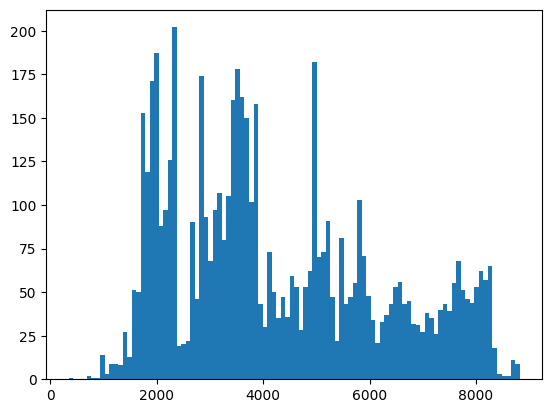

In [9]:
import matplotlib.pyplot as plt
plt.hist(all_lengths, bins=100)
plt.show()


## V4

make each memory action a real round

In [46]:

def trajectory_to_repeat_obs_samples_v4(traj):
    """
    Convert a merged trajectory to SFT training samples (multi-turn format).
    Each round becomes a separate user/assistant turn.
    """
    samples = []
    task_inst = traj['task_instruction']
    
    for current_round_idx in range(traj['total_rounds']):
        messages = []
        
        # Add system message
        messages.append({'role': 'system', 'content': memory_system_prompt})
        
        # Add history rounds as separate turns
        for prev_round in range(current_round_idx):
            prompt_list = []
            if prev_round == 0:
                prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}\n\n"})
            rd = traj['rounds'][prev_round]
            prompt_list.append({'type': 'text', 'text': f"Round {prev_round} observation:"})
            prompt_list.append({'type': 'memory_text', 'memory_text': {'text': rd['observation']}})
            messages.append({'role': 'user', 'content': prompt_list})
            messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': rd['action']}]})
        
        # Add current round
        prompt_list = []
        current_rd = traj['rounds'][current_round_idx]
        if current_round_idx == 0:
            prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}\n\n"})
        prompt_list.append({'type': 'text', 'text': f"Round {current_round_idx} observation: "})
        # repeat the current observation in textual format
        prompt_list.append({'type': 'text', 'text': f"{current_rd['observation']}"})
        prompt_list.append({'type': 'memory_text', 'memory_text': {'text': current_rd['observation']}, 'is_memory': False})
        messages.append({'role': 'user', 'content': prompt_list})
        messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': current_rd['action']}]})
        
        samples.append({
            "messages": messages,
            "task_instruction": task_inst,
            "round": current_round_idx,
            "total_rounds": traj['total_rounds']
        })
    
    return samples

In [47]:
v4_samples = []
for traj in processed_trajs:
    v4_samples.extend(trajectory_to_repeat_obs_samples_v4(traj))

print(f"Total SFT Memory samples: {len(v4_samples)}")
print(f"Sample distribution by round:")
round_dist = Counter([s['round'] for s in v4_samples])
print(round_dist)

Total SFT Memory samples: 9029
Sample distribution by round:
Counter({0: 1113, 1: 1072, 2: 1066, 3: 1007, 4: 948, 5: 872, 6: 748, 7: 626, 8: 471, 9: 269, 10: 165, 11: 98, 12: 74, 13: 62, 14: 46, 15: 43, 16: 39, 17: 34, 18: 33, 19: 31, 20: 28, 21: 26, 22: 24, 23: 23, 24: 22, 25: 21, 26: 18, 27: 5, 28: 3, 29: 3, 30: 3, 31: 3, 32: 3, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1})


In [49]:
v4_samples_parquet = pd.DataFrame({
    'messages': [
        json.dumps(s['messages'])
        for s in v4_samples
    ],
})
v4_samples_parquet.to_parquet("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_memory_multi_turn_sft.parquet")

In [3]:
memory_system_prompt_new="""# Setup
You are a professional web browsing agent assistant that can fulfill user's high-level instructions. 
Given the compressed tokens of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. 
# More details about the code
Your code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:

```
def do(action, argument, element):
	\"\"\"A single browsing operation on the webpage.
	Args:
		:param action: one of the actions from ["Click", "Right Click", "Type", "Search", "Hover", "Scroll Up", "Scroll Down", "Press Enter", "Switch Tab", "Select Dropdown Option", "Wait"].
		:param argument: optional. Only for "Type", "Search", "Switch Page", and "Select Dropdown Option", indicating the content to type in, page number(start from 0) to switch, or key to press.
		                           "Search" action is equivalent to "Type" action plus "Enter" key press.
		:param element: optional. Only for "Click", "Right Click", "Type", "Search", "Select Dropdown Option", and "Hover". Should be specific element id in the html.
	Returns:
		None. The webpage will be updated after executing the action.
	\"\"\"

def exit(message):
	\"\"\"Ending the browsing process if the assistant think it has fulfilled the goal.
	Args:
		:param message: optional. If user's instruction is a question, return assistant's answer in the message based on the browsing content.
	Returns:
		None.
	\"\"\"

def go_backward():
	\"\"\"Go back to the previous page.
	\"\"\"

def go_forward():
  \"\"\"Go forward to the next page.
  \"\"\"
```

Here are some examples:
- # Element: the 'REPORTS' section on the left sidebar
do(action="Click", element="7")
- # Element: the 'Period' dropdown, middle center
do(action="Select Dropdown Option", argument="Month", element="20")
- # Element: the 'From' date picker input field, middle center
do(action="Type", argument="01/01/2023", element="22")
- do(action="Scroll Down")
- exit(message="The top-3 best-selling products in January 2023 are: 1")
- # Element: The search bar
do(action="Search", argument="international airport near Carnegie Mellon University within a driving distance of 50 km", element="13")
- # Note: Pittsburgh International Airport, Southern Beltway, Findlay Township, Allegheny County, 15231, United States
# Element: The field labeled 'Pittsburgh International Airport' in the top left corner
do(action="Type", argument="Cleveland Hopkins International Airport", element="14")

REMEMBER: 
- only **ONE-LINE-OF-CODE** at a time
- Don't generate an operation element that you do not see in the screenshot.
- Use "# Element" to describe the element you choose in the html.
- Use '# Note" to record information useful to answer the instruction if needed.
- If you find yourself fallen into some sort of loop, try to use another method or change your action.
- If you think a page is still loading or still playing animation and you want to wait a while, use "Wait" action.
- You are acting in a real world, try your best not to reject user's demand. Solve all the problem you encounter.
- If you think you didn't get expected webpage, you should try using more precise and locative description of the element.
- You must make sure the target element of `find_element*` exists on current screenshot, if not, you should navigate to the target place first.
- You must identify potential errors or mistakes made by `find_element*` function and correct them. If the webpage is not as expected, you should try to re-do or un-do the operation.
- You should **NEVER** try to use the browser's address bar at the top of the page to navigate.
- Your answer shouldn't be in a code snippet format. Just write the function name and its arguments.
- For quote, exit, go_backward, go_forward request, you should strictly obey the format of quote, exit, go_backward, go_forward functions, answers like do("Quote", xxx, None) or  do("quote", xxx, None)are not allowed.
- If you use do function to perform "Click", "Right Click", "Type", "Search", "Select Dropdown Option", and "Hover", the param element must not be None.
- You must combine your memories and the current observation to form a comprehensive understanding of the current situation."""
def trajectory_to_repeat_obs_samples_v4_current_text_only(traj):
    """
    Convert a merged trajectory to SFT training samples (multi-turn format).
    Each round becomes a separate user/assistant turn.
    """
    samples = []
    task_inst = traj['task_instruction']
    
    for current_round_idx in range(traj['total_rounds']):
        messages = []
        
        # Add system message
        messages.append({'role': 'system', 'content': memory_system_prompt_new})
        
        # Add history rounds as separate turns
        for prev_round in range(current_round_idx):
            prompt_list = []
            if prev_round == 0:
                prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}\n\n"})
            rd = traj['rounds'][prev_round]
            prompt_list.append({'type': 'text', 'text': f"Round {prev_round} observation:"})
            prompt_list.append({'type': 'memory_text', 'memory_text': {'text': rd['observation']}})
            messages.append({'role': 'user', 'content': prompt_list})
            messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': rd['action']}]})
        
        # Add current round
        prompt_list = []
        current_rd = traj['rounds'][current_round_idx]
        if current_round_idx == 0:
            prompt_list.append({'type': 'text', 'text': f"Task Instruction: {task_inst}\n\n"})
        prompt_list.append({'type': 'text', 'text': f"Round {current_round_idx} observation: "})
        # repeat the current observation in textual format
        prompt_list.append({'type': 'text', 'text': f"{current_rd['observation']}"})
        messages.append({'role': 'user', 'content': prompt_list})
        messages.append({'role': 'assistant', 'content': [{'type': 'text', 'text': current_rd['action']}]})
        
        samples.append({
            "messages": messages,
            "task_instruction": task_inst,
            "round": current_round_idx,
            "total_rounds": traj['total_rounds']
        })
    
    return samples

In [5]:
from collections import Counter
v4_text_only_samples = []
for traj in processed_trajs:
    v4_text_only_samples.extend(trajectory_to_repeat_obs_samples_v4_current_text_only(traj))

print(f"Total SFT Memory samples: {len(v4_text_only_samples)}")
print(f"Sample distribution by round:")
round_dist = Counter([s['round'] for s in v4_text_only_samples])
print(round_dist)

Total SFT Memory samples: 9029
Sample distribution by round:
Counter({0: 1113, 1: 1072, 2: 1066, 3: 1007, 4: 948, 5: 872, 6: 748, 7: 626, 8: 471, 9: 269, 10: 165, 11: 98, 12: 74, 13: 62, 14: 46, 15: 43, 16: 39, 17: 34, 18: 33, 19: 31, 20: 28, 21: 26, 22: 24, 23: 23, 24: 22, 25: 21, 26: 18, 27: 5, 28: 3, 29: 3, 30: 3, 31: 3, 32: 3, 33: 2, 34: 2, 35: 2, 36: 2, 37: 2, 38: 2, 39: 2, 40: 2, 41: 2, 42: 2, 43: 2, 44: 1, 45: 1, 46: 1, 47: 1, 48: 1, 49: 1, 50: 1, 51: 1})


In [7]:
# from tqdm import tqdm
v4_text_only_samples_parquet = pd.DataFrame({
    'messages': [
        json.dumps(s['messages'])
        for s in v4_text_only_samples
    ],
})
v4_text_only_samples_parquet.to_parquet("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_memory_multi_turn_sft_text_only.parquet")

In [8]:
v4_text_only_samples[4]

{'messages': [{'role': 'system',
   'content': '# Setup\nYou are a professional web browsing agent assistant that can fulfill user\'s high-level instructions. \nGiven the compressed tokens of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. \n# More details about the code\nYour code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:\n\n```\ndef do(action, argument, element):\n\t"""A single browsing operation on the webpage.\n\tArgs:\n\t\t:param action: one of the actions from ["Click", "Right Click", "Type", "Search", "Hover", "Scroll Up", "Scroll Down", "Press Enter", "Switch Tab", "Select Dropdown Option", "Wait"].\n\t\t:param argument: optional. Only for "Type", "Search", "Switch Page", and "Select Dropdown Option", indicating

# Stress Test: Top 100 longest sequences with most memories

In [51]:
# Stress Test: Find top 100 samples with longest sequences and most memories
# For v4 format (multi-turn), we calculate:
# 1. num_memories: number of memory_text items in the sample
# 2. total_text_length: total character length of all text content
# 3. current_obs_length: length of the current observation (last user message)

from tqdm import tqdm

def count_memories_and_length(sample):
    """Count memories and calculate total length for a v4 sample."""
    messages = sample['messages']
    num_memories = 0
    total_text_length = 0
    current_obs_length = 0
    
    for msg in messages:
        content = msg['content']
        if isinstance(content, str):
            total_text_length += len(content)
        elif isinstance(content, list):
            for item in content:
                if item.get('type') == 'memory_text':
                    num_memories += 1
                    mem_text = item.get('memory_text', {}).get('text', '')
                    total_text_length += len(mem_text)
                elif item.get('type') == 'text':
                    total_text_length += len(item.get('text', ''))
    
    # Get current observation length (from the last user message)
    # In v4 format, the second-to-last message is the current user turn
    for msg in reversed(messages):
        if msg['role'] == 'user':
            content = msg['content']
            if isinstance(content, list):
                for item in content:
                    if item.get('type') == 'text':
                        current_obs_length += len(item.get('text', ''))
                    elif item.get('type') == 'memory_text':
                        current_obs_length += len(item.get('memory_text', {}).get('text', ''))
            break
    
    return {
        'num_memories': num_memories,
        'total_text_length': total_text_length,
        'current_obs_length': current_obs_length,
        'round': sample['round'],
        'total_rounds': sample['total_rounds'],
        'task_instruction': sample['task_instruction'][:100]
    }

# Analyze all v4 samples
print("Analyzing v4 samples...")
sample_stats = []
for idx, sample in enumerate(tqdm(v4_samples)):
    stats = count_memories_and_length(sample)
    stats['idx'] = idx
    sample_stats.append(stats)

# Sort by num_memories (primary) and total_text_length (secondary)
sample_stats_sorted = sorted(sample_stats, key=lambda x: (x['num_memories'], x['total_text_length']), reverse=True)

# Also sort by current_obs_length to find longest single observation
sample_stats_by_current_obs = sorted(sample_stats, key=lambda x: x['current_obs_length'], reverse=True)

print(f"\n=== Top 100 samples with most memories and longest sequences ===")
print(f"{'Rank':<6} {'Idx':<8} {'Memories':<10} {'TextLen':<12} {'CurObsLen':<12} {'Round':<8} {'TotalRounds':<12}")
print("-" * 80)
for i, stats in enumerate(sample_stats_sorted[:100]):
    print(f"{i+1:<6} {stats['idx']:<8} {stats['num_memories']:<10} {stats['total_text_length']:<12} {stats['current_obs_length']:<12} {stats['round']:<8} {stats['total_rounds']:<12}")

print(f"\n=== Top 20 samples with longest current observation ===")
print(f"{'Rank':<6} {'Idx':<8} {'CurObsLen':<12} {'Memories':<10} {'TextLen':<12} {'Round':<8} {'TotalRounds':<12}")
print("-" * 80)
for i, stats in enumerate(sample_stats_by_current_obs[:20]):
    print(f"{i+1:<6} {stats['idx']:<8} {stats['current_obs_length']:<12} {stats['num_memories']:<10} {stats['total_text_length']:<12} {stats['round']:<8} {stats['total_rounds']:<12}")

Analyzing v4 samples...


100%|██████████| 9029/9029 [00:00<00:00, 110457.87it/s]


=== Top 100 samples with most memories and longest sequences ===
Rank   Idx      Memories   TextLen      CurObsLen    Round    TotalRounds 
--------------------------------------------------------------------------------
1      4246     52         382315       10218        51       52          
2      4245     51         377292       10768        50       52          
3      4244     50         371929       11096        49       52          
4      4243     49         366504       11406        48       52          
5      4242     48         361053       11956        47       52          
6      4241     47         355098       12288        46       52          
7      4240     46         349075       12598        45       52          
8      4239     45         343028       13148        44       52          
9      917      44         336421       13298        43       44          
10     4238     44         336386       13298        43       52          
11     4237     43         3

In [54]:
stress_test_samples[0]

{'messages': [{'role': 'system',
   'content': '# Setup\nYou are a professional web browsing agent assistant that can fulfill user\'s high-level instructions. Given Simplified html of the browsed webpage at each step, you plan operations in python-style pseudo code using provided functions, or customize functions (if necessary) and then provide their implementations. \n# More details about the code\nYour code should be readable, simple, and only **ONE-LINE-OF-CODE** at a time, avoid using loop statement and only use if-else control if necessary. Predefined functions are as follow:\n\n```\ndef do(action, argument, element):\n\t"""A single browsing operation on the webpage.\n\tArgs:\n\t\t:param action: one of the actions from ["Click", "Right Click", "Type", "Search", "Hover", "Scroll Up", "Scroll Down", "Press Enter", "Switch Tab", "Select Dropdown Option", "Wait"].\n\t\t:param argument: optional. Only for "Type", "Search", "Switch Page", and "Select Dropdown Option", indicating the con

In [53]:
# Extract top 100 samples and save for stress testing
top_100_indices_by_num_memories = [stats['idx'] for stats in sample_stats_sorted[:100]]
top_100_indices_by_current_obs = [stats['idx'] for stats in sample_stats_by_current_obs[:100]]
top_100_indices = set(top_100_indices_by_num_memories) | set(top_100_indices_by_current_obs)
stress_test_samples = [v4_samples[idx] for idx in top_100_indices]

print(f"Selected {len(stress_test_samples)} samples for stress testing")
num_memories = [s['round'] for s in stress_test_samples]
min_memories = min(num_memories)
max_memories = max(num_memories)
print(f"  Min memories: {min_memories}")
print(f"  Max memories: {max_memories}")

tokenized_length = [len(qwen_memory_tokenizer.apply_chat_template(s['messages'], tokenize=True)) for s in stress_test_samples]
min_tokenized_length = min(tokenized_length)
max_tokenized_length = max(tokenized_length)
print(f"  Min tokenized length: {min_tokenized_length}")
print(f"  Max tokenized length: {max_tokenized_length}")


Selected 200 samples for stress testing
  Min memories: 0
  Max memories: 51
  Min tokenized length: 3546
  Max tokenized length: 10092


In [55]:
# Save to parquet
stress_test_df = pd.DataFrame({
    'messages': [json.dumps(s['messages']) for s in stress_test_samples],
})
stress_test_output_path = "/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_stress_test_top200.parquet"
stress_test_df.to_parquet(stress_test_output_path)
print(f"\nSaved stress test samples to: {stress_test_output_path}")


Saved stress test samples to: /fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/webarena_stress_test_top200.parquet


In [45]:
type(stress_test_df.iloc[0]['messages'])

str

In [ ]:
# Visualize the distribution of memories and text length
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of num_memories for all samples
ax1 = axes[0, 0]
all_memories = [s['num_memories'] for s in sample_stats]
ax1.hist(all_memories, bins=50, edgecolor='black', alpha=0.7)
ax1.axvline(x=sample_stats_sorted[99]['num_memories'], color='r', linestyle='--', label=f'Top 100 threshold: {sample_stats_sorted[99]["num_memories"]}')
ax1.set_xlabel('Number of Memories')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of Memory Count (All Samples)')
ax1.legend()

# 2. Histogram of text length for all samples
ax2 = axes[0, 1]
all_text_lengths = [s['total_text_length'] for s in sample_stats]
ax2.hist(all_text_lengths, bins=50, edgecolor='black', alpha=0.7)
ax2.axvline(x=min(s['total_text_length'] for s in sample_stats_sorted[:100]), color='r', linestyle='--', label='Top 100 min')
ax2.set_xlabel('Total Text Length (chars)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of Text Length (All Samples)')
ax2.legend()

# 3. Scatter plot: memories vs text length (top 100 highlighted)
ax3 = axes[1, 0]
top_100_set = set(top_100_indices)
colors = ['red' if s['idx'] in top_100_set else 'blue' for s in sample_stats]
alphas = [1.0 if s['idx'] in top_100_set else 0.1 for s in sample_stats]
for s, c, a in zip(sample_stats, colors, alphas):
    ax3.scatter(s['num_memories'], s['total_text_length'], c=c, alpha=a, s=10)
ax3.set_xlabel('Number of Memories')
ax3.set_ylabel('Total Text Length (chars)')
ax3.set_title('Memories vs Text Length (Red = Top 100)')

# 4. Round distribution for top 100
ax4 = axes[1, 1]
top_100_rounds = [s['round'] for s in sample_stats_sorted[:100]]
round_counts = Counter(top_100_rounds)
rounds_sorted = sorted(round_counts.keys())
ax4.bar(rounds_sorted, [round_counts[r] for r in rounds_sorted], edgecolor='black')
ax4.set_xlabel('Round Number')
ax4.set_ylabel('Count in Top 100')
ax4.set_title('Round Distribution of Top 100 Stress Test Samples')

plt.tight_layout()
plt.savefig("/fs/ess/PAS1576/qwjian/agent-memory-lab/external/LLaMA-Factory/remake_dataset/webarena/stress_test_distribution.png", dpi=150)
plt.show()
print("Saved visualization to stress_test_distribution.png")

In [ ]:
# Estimate token counts for top 100 samples using qwen tokenizer
print("Estimating token counts for top 100 stress test samples...")

def estimate_tokens_for_sample(sample, tokenizer):
    """Estimate total tokens for a sample (excluding special memory encoding)."""
    messages = sample['messages']
    total_tokens = 0
    
    for msg in messages:
        content = msg['content']
        if isinstance(content, str):
            total_tokens += len(tokenizer.encode(content))
        elif isinstance(content, list):
            for item in content:
                if item.get('type') == 'memory_text':
                    mem_text = item.get('memory_text', {}).get('text', '')
                    total_tokens += len(tokenizer.encode(mem_text))
                elif item.get('type') == 'text':
                    total_tokens += len(tokenizer.encode(item.get('text', '')))
    
    return total_tokens

token_counts = []
for sample in tqdm(stress_test_samples):
    tokens = estimate_tokens_for_sample(sample, qwen_tokenizer)
    token_counts.append(tokens)

print(f"\nToken count statistics for top 100 stress test samples:")
print(f"  Min tokens: {min(token_counts)}")
print(f"  Max tokens: {max(token_counts)}")
print(f"  Mean tokens: {sum(token_counts) / len(token_counts):.1f}")
print(f"  Median tokens: {sorted(token_counts)[len(token_counts)//2]}")

# Show the most extreme samples
print(f"\nTop 10 samples by token count:")
token_with_idx = list(zip(token_counts, range(len(token_counts))))
token_with_idx_sorted = sorted(token_with_idx, reverse=True)
for tokens, idx in token_with_idx_sorted[:10]:
    orig_idx = top_100_indices[idx]
    stats = sample_stats_sorted[idx]
    print(f"  Tokens: {tokens:>8}, Memories: {stats['num_memories']:>3}, Round: {stats['round']:>2}/{stats['total_rounds']}")